Работа с табличными данными

In [77]:
import pandas as pd

In [78]:
df = pd.read_csv('train.csv', sep="|")
df

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


In [79]:
df.dtypes

trustLevel                     int64
totalScanTimeInSeconds         int64
grandTotal                   float64
lineItemVoids                  int64
scansWithoutRegistration       int64
quantityModifications          int64
scannedLineItemsPerSecond    float64
valuePerSecond               float64
lineItemVoidsPerPosition     float64
fraud                          int64
dtype: object

In [80]:
df.isna().sum()

trustLevel                   0
totalScanTimeInSeconds       0
grandTotal                   0
lineItemVoids                0
scansWithoutRegistration     0
quantityModifications        0
scannedLineItemsPerSecond    0
valuePerSecond               0
lineItemVoidsPerPosition     0
fraud                        0
dtype: int64

In [81]:
df.fraud.value_counts()

fraud
0    1775
1     104
Name: count, dtype: int64

In [82]:
y = df["fraud"]
X = df.drop(columns=["fraud"])

In [83]:
df.describe()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
count,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000
mean,3.401809,932.153273,50.864492,5.469931,4.904204,2.525279,0.058138,0.201746,0.745404,0.055349
std,1.709404,530.144640,28.940202,3.451169,3.139697,1.695472,0.278512,1.242135,1.327241,0.228720
min,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000548,0.000007,0.000000,0.000000
25%,2.000000,474.500000,25.965000,2.000000,2.000000,1.000000,0.008384,0.027787,0.160000,0.000000
50%,3.000000,932.000000,51.210000,5.000000,5.000000,3.000000,0.016317,0.054498,0.350000,0.000000
75%,5.000000,1397.000000,77.285000,8.000000,8.000000,4.000000,0.032594,0.107313,0.666667,0.000000
max,6.000000,1831.000000,99.960000,11.000000,10.000000,5.000000,6.666667,37.870000,11.000000,1.000000


## Предобработка данных

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [85]:
X_train.shape

(1503, 9)

In [86]:
X_val.shape

(376, 9)

In [87]:
X_test = pd.read_csv("test.csv", sep="|")
X_test

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition
0,4,467,88.48,4,8,4,0.014989,0.189465,0.571429
1,3,1004,58.99,7,6,1,0.026892,0.058755,0.259259
2,1,162,14.00,4,5,4,0.006173,0.086420,4.000000
3,5,532,84.79,9,3,4,0.026316,0.159380,0.642857
4,5,890,42.16,4,0,0,0.021348,0.047371,0.210526
...,...,...,...,...,...,...,...,...,...
498116,4,783,59.10,2,2,0,0.012771,0.075479,0.200000
498117,1,278,98.90,9,5,4,0.050360,0.355755,0.642857
498118,3,300,5.41,6,6,4,0.030000,0.018033,0.666667
498119,2,1524,33.97,2,5,3,0.005906,0.022290,0.222222


In [88]:
y_test = pd.read_csv("DMC-2019-realclass.csv", sep="|")["fraud"]
y_test.value_counts()

fraud
0    474394
1     23727
Name: count, dtype: int64

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [90]:
import torch

In [91]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [92]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [93]:
from torch.utils.data import TensorDataset, DataLoader

In [94]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1024)

вес для редкого класса, чтобы модель его не пропускала

In [95]:
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

In [96]:
pos_weight = n_neg / n_pos
pos_weight

tensor(17.1084)

## Модель

In [97]:
import torch.nn as nn

In [98]:
model = nn.Sequential(
    nn.Linear(9, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

In [99]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [100]:
for epoch in range(30):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

    print("эпоха", epoch, "loss", round(loss.item(), 4))

эпоха 0 loss 0.7619
эпоха 1 loss 0.7604
эпоха 2 loss 1.3704
эпоха 3 loss 0.6135
эпоха 4 loss 0.8806
эпоха 5 loss 0.9829
эпоха 6 loss 1.1062
эпоха 7 loss 0.7191
эпоха 8 loss 0.4694
эпоха 9 loss 0.1907
эпоха 10 loss 0.1987
эпоха 11 loss 0.2726
эпоха 12 loss 0.5823
эпоха 13 loss 0.4203
эпоха 14 loss 0.5777
эпоха 15 loss 0.2641
эпоха 16 loss 0.3274
эпоха 17 loss 0.7236
эпоха 18 loss 0.1926
эпоха 19 loss 0.3134
эпоха 20 loss 0.7188
эпоха 21 loss 0.3172
эпоха 22 loss 0.5604
эпоха 23 loss 0.3514
эпоха 24 loss 0.0545
эпоха 25 loss 0.129
эпоха 26 loss 0.1091
эпоха 27 loss 0.2914
эпоха 28 loss 0.1675
эпоха 29 loss 0.1812


## Проверка

In [101]:
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)

probs[:5]

tensor([[7.4067e-04],
        [2.2004e-01],
        [3.5729e-06],
        [1.2523e-04],
        [2.4232e-05]])

In [102]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = y_test.numpy()
y_prob = probs.numpy()

In [103]:
roc_auc_score(y_true, y_prob)

0.9726332206095025

In [104]:
from sklearn.metrics import precision_score, recall_score

In [105]:
y_pred = (y_prob > 0.5).astype(int)

In [106]:
precision_score(y_true, y_pred)

0.34099785050407194

In [107]:
recall_score(y_true, y_pred)

0.9494247060311038

## Попробуем подобрать порог

In [108]:
with torch.no_grad():
    val_prob = torch.sigmoid(model(X_val)).numpy()

val_true = y_val.numpy()

In [109]:
from sklearn.metrics import precision_recall_curve

target_recall = 0.90

prec, rec, thr = precision_recall_curve(val_true, val_prob)
best_threshold = thr[rec[:-1] >= target_recall].max()
best_threshold

np.float32(0.68088645)

In [110]:
y_pred = (y_prob > best_threshold).astype(int)

In [111]:
precision_score(y_true, y_pred)

0.40619136960600377

In [112]:
recall_score(y_true, y_pred)

0.8759640915412821

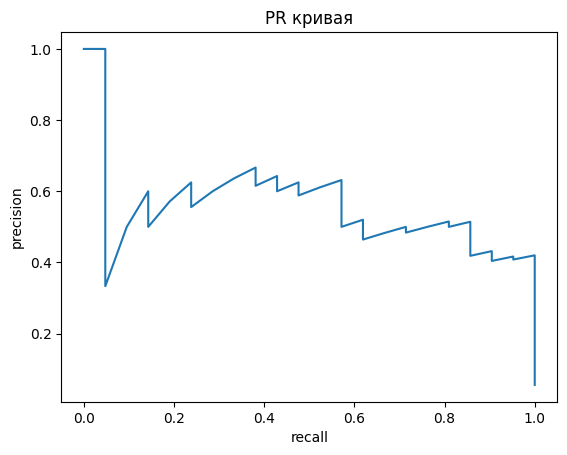

In [113]:
import matplotlib.pyplot as plt

plt.plot(rec, prec)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR кривая")
plt.show()

# ансамбль

In [ ]:
import numpy as np

In [ ]:
def build_model():
    return nn.Sequential(
        nn.Linear(9, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        )

In [115]:
loss_fn2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [116]:
test_probs = []

for seed in range(5):
    torch.manual_seed(seed)
    net = build_model()
    opt = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)

    net.train()
    for epoch in range(120):
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn2(net(xb), yb)
            loss.backward()
            opt.step()

    net.eval()
    with torch.no_grad():
        test_probs.append(torch.sigmoid(net(X_test)).numpy())

    print("сеть", seed, "обучена")

probs2 = np.mean(test_probs, axis=0)

сеть 0 обучена
сеть 1 обучена
сеть 2 обучена
сеть 3 обучена
сеть 4 обучена


In [117]:
roc_auc_score(y_true, probs2)

0.9819678838542818

In [118]:
average_precision_score(y_true, probs2)

0.7559112712850714